# Seasonal Patterns in Amphibian Observations Using the iNaturalist API

This project uses the iNaturalist API to retrieve amphibian observations
and examine how the number of observations varies throughout the year.

In [1]:
import requests
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
url = "https://api.inaturalist.org/v1/observations"

params = {
    "taxon_id": 20978,   # Amphibia
    "per_page": 10
}

response = requests.get(url, params=params)

print(response.status_code)

200


In [3]:
data = response.json()

print(data.keys())

dict_keys(['total_results', 'page', 'per_page', 'results'])


In [4]:
print(len(data["results"]))

10


In [5]:
first_observation = data["results"][0]

print(first_observation)

{'quality_grade': 'needs_id', 'time_observed_at': '2026-10-08T11:02:26-04:00', 'taxon_geoprivacy': None, 'annotations': [], 'uuid': '2c64109c-ab6e-400b-b78a-637f62587757', 'observed_on_details': {'date': '2026-10-08', 'day': 8, 'month': 10, 'year': 2026, 'hour': 11, 'week': 41}, 'id': 406797884, 'cached_votes_total': 0, 'identifications_most_agree': False, 'created_at_details': {'date': '2026-10-08', 'day': 8, 'month': 10, 'year': 2026, 'hour': 11, 'week': 41}, 'species_guess': None, 'identifications_most_disagree': False, 'tags': [], 'positional_accuracy': 4, 'comments_count': 0, 'site_id': 1, 'created_time_zone': 'America/New_York', 'license_code': 'cc-by-nc', 'observed_time_zone': 'America/New_York', 'quality_metrics': [], 'public_positional_accuracy': 4, 'reviewed_by': [3796159], 'oauth_application_id': 3, 'flags': [], 'created_at': '2026-10-08T11:02:57-04:00', 'description': '', 'time_zone_offset': '-05:00', 'project_ids_with_curator_id': [], 'observed_on': '2026-10-08', 'observed

In [6]:
print("Date:", first_observation["observed_on"])
print("Species:", first_observation["taxon"]["name"])
print("Common name:", first_observation["taxon"].get("preferred_common_name"))

Date: 2026-10-08
Species: Notophthalmus viridescens
Common name: Eastern Newt


In [7]:
params = {
    "taxon_id": 20978,   # Amphibia
    "per_page": 200
}

response = requests.get(url, params=params)
data = response.json()

print("Number of observations retrieved:", len(data["results"]))

Number of observations retrieved: 200


In [8]:
monthly_counts = []

for month in range(1, 13):
    params = {
        "taxon_id": 20978,   # Amphibia
        "year": 2025,
        "month": month,
        "per_page": 200
    }

    response = requests.get(url, params=params)
    data = response.json()

    monthly_counts.append(data["total_results"])

print(monthly_counts)

[26801, 33415, 66593, 92833, 97769, 86376, 84701, 85540, 80294, 61397, 45365, 30624]


In [9]:
months = [
    "January", "February", "March", "April",
    "May", "June", "July", "August",
    "September", "October", "November", "December"
]

monthly_data = pd.DataFrame({
    "Month": months,
    "Observations": monthly_counts
})

print(monthly_data)

        Month  Observations
0     January         26801
1    February         33415
2       March         66593
3       April         92833
4         May         97769
5        June         86376
6        July         84701
7      August         85540
8   September         80294
9     October         61397
10   November         45365
11   December         30624


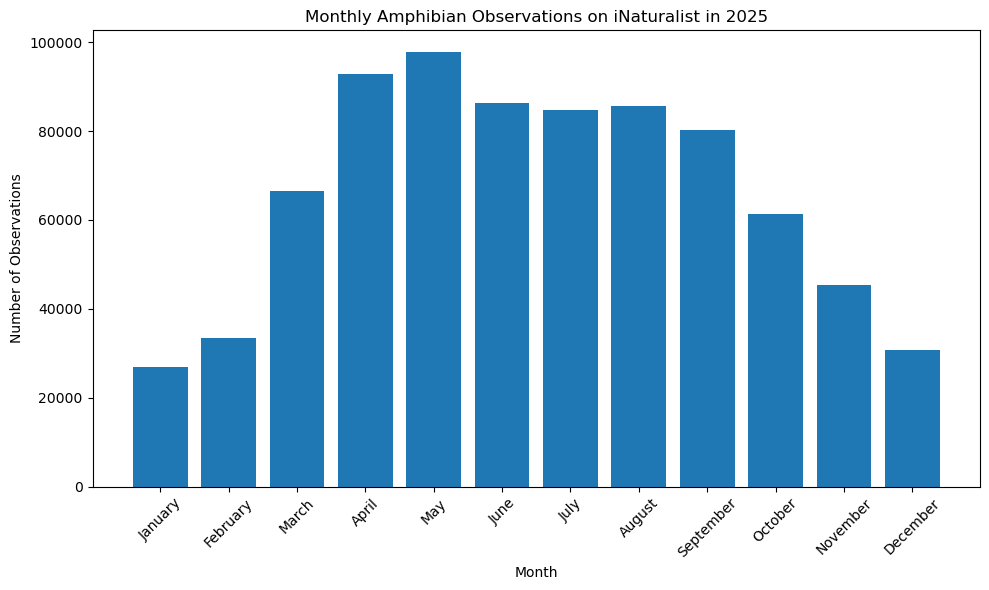

In [10]:
plt.figure(figsize=(10, 6))

plt.bar(monthly_data["Month"], monthly_data["Observations"])

plt.title("Monthly Amphibian Observations on iNaturalist in 2025")
plt.xlabel("Month")
plt.ylabel("Number of Observations")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

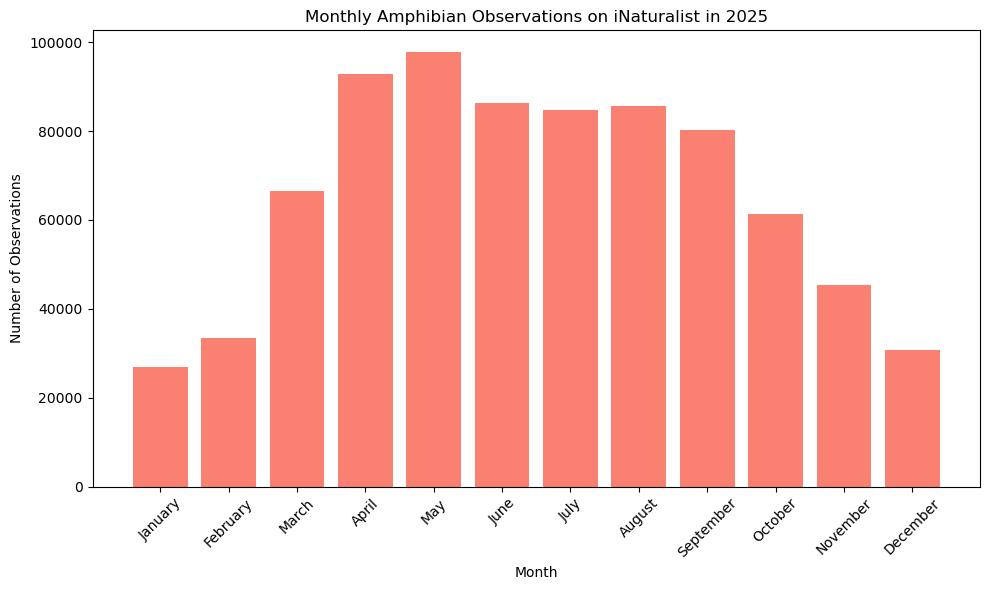

In [11]:
plt.figure(figsize=(10, 6))

plt.bar(
    monthly_data["Month"],
    monthly_data["Observations"],
    color="#FA8072"
)

plt.title("Monthly Amphibian Observations on iNaturalist in 2025")
plt.xlabel("Month")
plt.ylabel("Number of Observations")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## Results

Amphibian observations showed a strong seasonal pattern during the year of 2025.
The number of observations increased from 26,800 in January to a peak
of 97,759 in May. These Observations remained relatively high throughout the
summer and declined during the fall and winter.

Importantly, these data represent observations that were submitted to 
iNaturalist rather than direct measurements of amphibian abundance. 
Therefore, we might be able to assume that the observed seasonal pattern 
may reflect both seasonal amphibian activity and variation in human observation effort.

In [12]:
params = {
    "taxon_id": 20978,   # Amphibia
    "year": 2025,
    "per_page": 200
}

response = requests.get(url, params=params)
data = response.json()

observations = data["results"]

print("Observations retrieved:", len(observations))

Observations retrieved: 200


In [13]:
species_names = []

for observation in observations:
    taxon = observation.get("taxon")

    if taxon is not None:
        species_names.append(taxon.get("preferred_common_name"))

print(species_names[:10])

['Green Frog', 'Gray Treefrog', 'European Toad', "Cope's Gray Tree Frog", 'Palearctic Treefrogs', 'Fire Salamander', 'Water Frogs', 'Water Frogs', 'Water Frogs', 'Green Tree Frog']


In [14]:
species_counts = pd.Series(species_names).value_counts()

print(species_counts.head(10))

American Toad                    13
Water Frogs                       8
Frogs and Toads                   8
American Bullfrog                 7
Grey Foam-nest Tree Frog          6
Gray Treefrog                     5
European Toad                     5
Asian Common Toad                 5
Gray Treefrog Species Complex     5
European Common Frog              5
Name: count, dtype: int64


In [15]:
species_names = []

for observation in observations:
    taxon = observation.get("taxon")

    if taxon is not None and taxon.get("rank") == "species":
        species_names.append(taxon.get("preferred_common_name"))

species_counts = pd.Series(species_names).value_counts()

print(species_counts.head(10))

American Toad               13
American Bullfrog            7
Grey Foam-nest Tree Frog     6
Gray Treefrog                5
European Toad                5
Asian Common Toad            5
European Common Frog         5
Green Frog                   4
Eastern Newt                 4
Cope's Gray Tree Frog        3
Name: count, dtype: int64


In [16]:
taxon.get("rank") == "species"

False

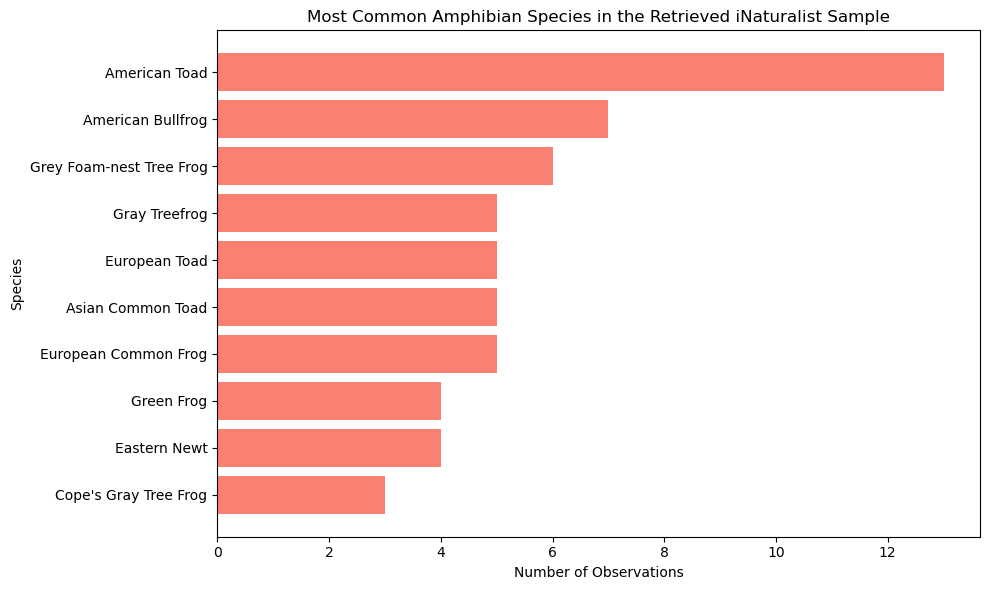

In [17]:
top_10 = species_counts.head(10)

plt.figure(figsize=(10, 6))

plt.barh(
    top_10.index,
    top_10.values,
    color="#FA8072"
)

plt.title("Most Common Amphibian Species in the Retrieved iNaturalist Sample")
plt.xlabel("Number of Observations")
plt.ylabel("Species")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

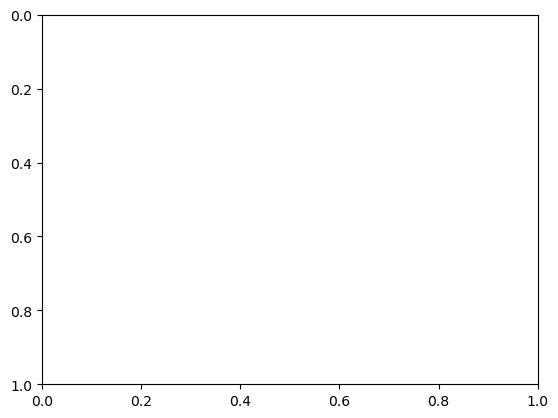

In [18]:
plt.gca().invert_yaxis()

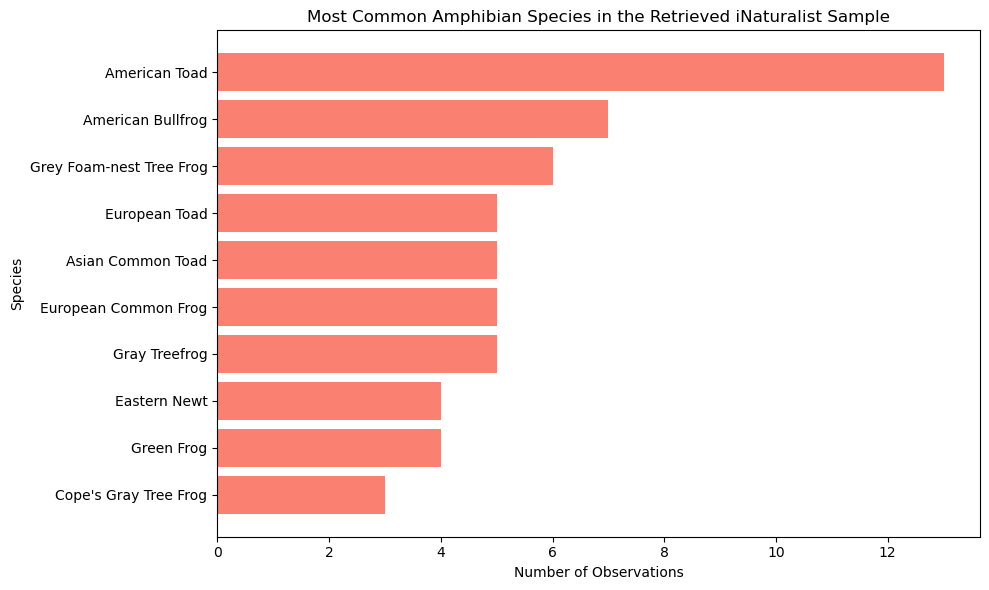

In [19]:
top_10 = species_counts.head(10).sort_values()

plt.figure(figsize=(10, 6))

plt.barh(
    top_10.index,
    top_10.values,
    color="#FA8072"
)

plt.title("Most Common Amphibian Species in the Retrieved iNaturalist Sample")
plt.xlabel("Number of Observations")
plt.ylabel("Species")

plt.tight_layout()
plt.show()

## Species-Level Observations

The individual observation records returned by the iNaturalist API were also
used to examine which species occurred most frequently in the retrieved sample.
Only observations identified to the species level were included, excluding
records identified only to broader taxonomic groups.

The ten most frequently occurring species in the 200 retrieved observations
were visualized using a horizontal bar graph. While informative, this represents 
the composition of the retrieved API sample and therefore should not be interpreted 
as the ten most abundant amphibian species overall.

## Conclusion

Using the iNaturalist API, I retrieved and processed amphibian observation data
from 2025. Monthly observation totals showed a strong seasonal pattern, with
observations increasing during spring, peaking in May, and declining toward
winter. I also extracted taxonomic information from individual API records to
compare the most frequently represented species in a sample of observations.

These results demonstrate how API data can be filtered, organized, summarized,
and visualized in Python rather than simply displaying the raw API response.